# Linear Regression from Scratch

**Linear Regression** is a machine learning algorithm used to predict a **continuous numeric value** (like a price or a salary) — not a category or class.

It works by finding the best-fitting **straight line** (or hyperplane, if there is more than one input feature) through the data points. This line is described by a simple equation:

$$y = wx + b$$

- `w` (weight) controls the **slope** of the line.
- `b` (bias) controls where the line **crosses** the y-axis.

The goal of training is to find the values of `w` and `b` that make the line fit the data as closely as possible. The animation below shows exactly that: the line starts flat and gradually adjusts itself to fit the data as training progresses.

![Linear Regression Animation](GIF/linear_regression.gif)

## 1. Load the Data

We start by loading the dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('datasets/Linear Regression.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


**About this dataset:** it has one input feature, `YearsExperience`, and one target variable, `Salary`.
Since `Salary` is a continuous number (not a category), this is a **regression problem**.

## 2. Select Features and Target

In [3]:
X = df[['YearsExperience']].values   # input feature
y = df['Salary'].values              # target variable

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 1)
y shape: (30,)


## 3. Train/Test Split (Manual)

We split the data into a **training set** (used to fit the model) and a **test set** (used to check how well it generalizes). We do this manually by shuffling the row indices and slicing them 80/20.

In [13]:
np.random.seed(42)  # for reproducible results

n_samples = X.shape[0]
indices = np.arange(n_samples)
np.random.shuffle(indices)

split_point = int(0.8 * n_samples)
train_idx, test_idx = indices[:split_point], indices[split_point:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 24
Test samples: 6


## 4. Feature Scaling

We standardize the feature so it has a mean of 0 and a standard deviation of 1:

$$X_{scaled} = \frac{X - mean}{std}$$

This helps Gradient Descent converge faster and more reliably, since the feature and the cost function are on a more balanced scale. Note: we compute the mean/std **only from the training set**, then apply it to both sets, to avoid leaking test information into training.

In [5]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

## 5. Linear Regression From Scratch

Now we implement Linear Regression using only NumPy. The model learns by repeating these steps:

1. **Predict:** `y_pred = X·w + b`
2. **Measure error** with the Mean Squared Error (MSE) cost function:  $J(w,b) = \frac{1}{n}\sum (y_{pred} - y)^2$
3. **Compute gradients** — the direction in which `w` and `b` should change to reduce the cost.
4. **Update** `w` and `b` a small step in that direction (this is Gradient Descent).

Repeating this many times gradually finds the line that best fits the data.

In [6]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)   # start weights at zero
        self.b = 0.0                    # start bias at zero

        for _ in range(self.n_iterations):
            # 1. Predictions: y_pred = Xw + b
            y_pred = X.dot(self.w) + self.b

            # 2. Cost function (Mean Squared Error)
            error = y_pred - y
            cost = (1 / n_samples) * np.sum(error ** 2)
            self.loss_history.append(cost)

            # 3. Gradients of the cost w.r.t. w and b
            dw = (2 / n_samples) * X.T.dot(error)
            db = (2 / n_samples) * np.sum(error)

            # 4. Update parameters (Gradient Descent step)
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return X.dot(self.w) + self.b

## 6. Training the Model

We train the model on the scaled training data and track the loss at every iteration. If training is working correctly, the loss should **decrease** and eventually flatten out as the model converges to the best `w` and `b`.

In [7]:
model = LinearRegressionScratch(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_scaled, y_train)

print("Learned weight (w):", model.w)
print("Learned bias (b):", model.b)
print("Final training loss:", model.loss_history[-1])

Learned weight (w): [28412.78979071]
Learned bias (b): 77311.99999999997
Final training loss: 29514845.14216577


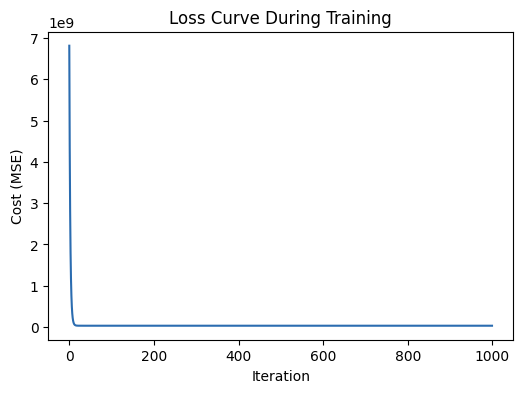

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(model.loss_history, color='#2b6cb0')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Loss Curve During Training')
plt.show()

As training progresses, Gradient Descent keeps nudging `w` and `b` in the direction that reduces the cost, which is why the loss curve drops quickly at first and then flattens out once the model is close to its best fit.

## 7. Predictions

We use the trained model to predict `Salary` values on the unseen test set.

In [9]:
y_pred_test = model.predict(X_test_scaled)

for actual, predicted in zip(y_test, y_pred_test):
    print(f"Actual: {actual:.2f}   Predicted: {predicted:.2f}")

Actual: 91738.00   Predicted: 89579.99
Actual: 54445.00   Predicted: 55607.10
Actual: 63218.00   Predicted: 62212.94
Actual: 61111.00   Predicted: 67875.09
Actual: 93940.00   Predicted: 82030.46
Actual: 60150.00   Predicted: 53719.72


## 8. Model Evaluation

We evaluate the model on the test set using two metrics:

- **MSE**: the average squared prediction error (lower is better).
- **R² score**: how much of the variance in the target the model explains (closer to 1 is better).

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

In [10]:
mse = np.mean((y_pred_test - y_test) ** 2)

ss_res = np.sum((y_test - y_pred_test) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"Test MSE: {mse:.2f}")
print(f"Test R^2: {r2:.4f}")

Test MSE: 39326046.04
Test R^2: 0.8433


## 9. Visualization

Since there is only **one input feature**, we can plot the actual data points together with the fitted regression line in a single 2D plot.

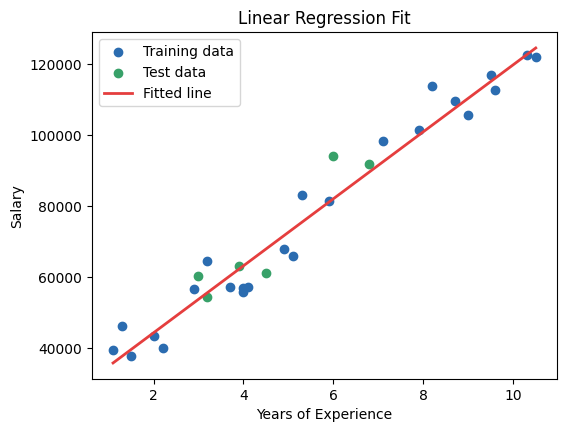

In [11]:
# Build a smooth line across the full range of X, using the same scaling as training
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_line_scaled = (x_line - mean) / std
y_line = model.predict(x_line_scaled)

plt.figure(figsize=(6, 4.5))
plt.scatter(X_train, y_train, color='#2b6cb0', label='Training data')
plt.scatter(X_test, y_test, color='#38a169', label='Test data')
plt.plot(x_line, y_line, color='#e53e3e', linewidth=2, label='Fitted line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

## Conclusion

- **Linear Regression** predicts a continuous value by fitting a straight line, `y = wx + b`, through the data.
- The **cost function (MSE)** measures how far the model's predictions are from the actual values — the lower, the better.
- **Gradient Descent** repeatedly adjusts `w` and `b` in the direction that reduces the cost, gradually improving the fit.
- Once trained, the model makes **predictions** on new data simply by plugging values into the learned line equation.